In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr


In [8]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

PR = 40
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}"
u_file = f"{base_path}/u/PR{PR}_500_20000day_u_6hourly.h5"

# --- Load data ---
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])  # shape: (time, lev, lat, lon)


In [9]:
def Cal_EOF_PC_for_barotropic(input_data):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [10]:
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u[:,:,32:].mean(axis=(1,3)))


n_component: 32


In [11]:
# PC1 *= -1
# EOF1 *= -1

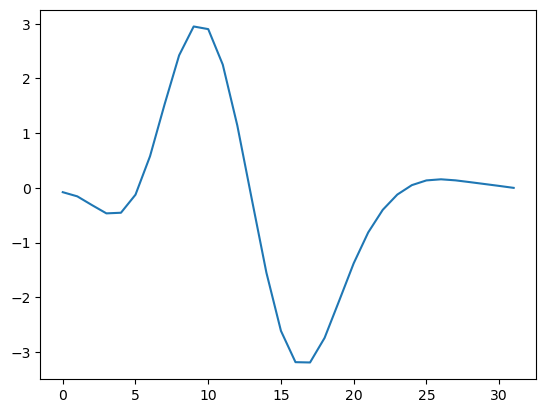

In [13]:
plt.figure()
plt.plot(EOF1)

# PC1 
# PR0: No
# PR10: *= -1 
# PR20: *= -1 
# PR30: No
# PR40: *= -1
# PR50: No

In [47]:
time_idx_pos_test = np.where(PC1 >  PC1.std() * 1 + PC1.mean())
time_idx_neg_test = np.where(PC1 <  -PC1.std() * 1 + PC1.mean())

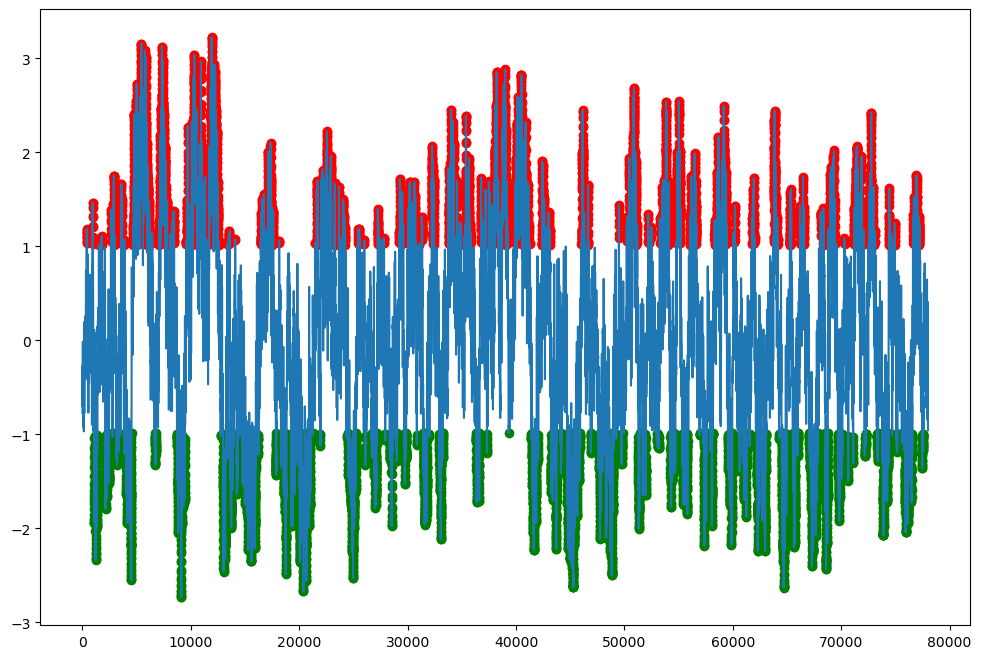

In [48]:
# Select the values from PC1[0] that satisfy the condition
PC1_big = PC1[time_idx_pos_test]
PC1_sml = PC1[time_idx_neg_test]

time_idx_pos_test = np.array(time_idx_pos_test)
time_idx_pos_test_lag = time_idx_pos_test + 400
time_idx_pos_test_lag = time_idx_pos_test_lag[time_idx_pos_test_lag<78000]

PC1_big_lag = PC1[time_idx_pos_test_lag]

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx,yy = np.meshgrid(x,y)
days = np.linspace(0,78000,78000)

# Plot the data
plt.figure(figsize=(12,8), dpi=100.)
plt.plot(days, PC1)
plt.scatter(days[time_idx_pos_test], PC1_big, color="red")
plt.scatter(days[time_idx_neg_test], PC1_sml, color="green")
# plt.scatter(days[time_idx_pos_test_lag], PC1_big_lag, color="Black")


# plt.xlim([68000,78000])
plt.show()

In [49]:
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.h5", 'w') as f:
    f.create_dataset("time_idx_pos", data=time_idx_pos)

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negitive_1std_PR{PR}.h5", 'w') as f:
    f.create_dataset("time_idx_neg", data=time_idx_neg)


# Calcualte u dot PC1 to get EOF1_2D

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

PR = 50
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}"
u_file = f"{base_path}/u/PR{PR}_500_20000day_u_6hourly.h5"

# --- Load data ---
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])  # shape: (time, lev, lat, lon)


In [ ]:
# --- Latitude array for weighting (assuming 64 latitudes from 0° to 90°) ---
n_lat = u.shape[2]
lat = np.linspace(0, 90, n_lat)
lat_weight = np.sqrt(np.cos(np.deg2rad(lat[32:])))  # (32,) for latitudes >= 32

# --- Calculate EOF and PC ---
def Cal_EOF_PC_for_barotropic(input_data: np.ndarray, lat_weight: np.ndarray):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF

    # Apply latitude weighting
    input_weighted = input_data * lat_weight[np.newaxis, :]

    # Number of components for EOF
    n_component = min(input_weighted.shape[0], input_weighted.shape[1])

    # Perform EOF analysis
    eof_instance = EOF((input_weighted,), n_components=n_component, field="1D")
    eof_instance.get()

    # Get and normalize EOFs and PCs
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()

    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

# --- Apply EOF to barotropic u (time, y), using mean over pressure and longitude ---
ubar = u[:, :, 32:, :].mean(axis=(1, 3))  # shape: (time, lat=32)
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(ubar, lat_weight)


# PR0: no need to plus -1
# PR10: plus -1 
# PR20: plus -1 
# PR30: no need to plus -1
# PR40: plus -1
# PR50: no need to plus -1

In [ ]:
# PC1 *= -1
# EOF1 *= -1

In [ ]:
# --- Optional: Check EOF1 direction ---
plt.figure()
plt.plot(EOF1)
plt.title("EOF1 (barotropic mode)")
plt.xlabel("Latitude index (32 to end)")
# plt.grid(True)
plt.show()



In [ ]:
# --- Compute EOF1 projection onto reshaped u field ---
u_reshape = np.mean(u[:, :, 32:, :], axis=3).reshape(ubar.shape[0], -1)  # shape: (time, lev*lat=20*32)
PC1_column = PC1.reshape(-1, 1)
EOF1_dot = u_reshape.T @ PC1_column / (PC1 @ PC1_column)  # shape: (lev*lat, 1)
EOF1_dot_reshape = EOF1_dot.reshape((u.shape[1], u.shape[2] - 32))  # shape: (20, 32)

In [ ]:
def plot_contourf_near0_fixcolorbar_EOF(X, Y ,var_near0, axs, cbar_lim, shading_levels = 11, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        cbar = plt.colorbar(cs, spacing="proportional")#cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # plt.title("c) EOF1", fontsize=14)
        # plt.xlabel("Latitude")
        ax.set_ylabel("Sigma")
        ax.invert_yaxis()
        # plt.ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

In [ ]:
y = np.linspace(-90,90,64)

fig, ax = plt.subplots(1)
_,custom_levels_bar,cs=plot_contourf_near0_fixcolorbar_EOF(y[32:], np.linspace(0,1,20), EOF1_dot_reshape, ax, cbar_lim = [-9, 9],my_cmap = 'RdBu_r')


In [ ]:
# --- Save to HDF5 ---
save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_EOF1/PR{PR}_500_20000day_EOF1_2D.h5"
with h5py.File(save_path, "w") as f:
    f.create_dataset("EOF1_dot", data=EOF1_dot_reshape)
    f.attrs["description"] = "EOF1: zonal mean u projection onto PC1"
    f.attrs["dimensions"] = "(level, latitude>=32)"
    f.attrs["PR"] = PR
print(f"Saved EOF1 projection to {save_path}")